In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
customer = pd.read_csv("../data/raw/customers.csv")
geography = pd.read_csv("../data/raw/geography.csv")
inventory = pd.read_csv("../data/raw/inventory.csv")
order_items = pd.read_csv("../data/raw/order_items.csv" , low_memory= False)
order = pd.read_csv("../data/raw/orders.csv")
payment = pd.read_csv("../data/raw/payments.csv")
product = pd.read_csv("../data/raw/products.csv")
promotion = pd.read_csv("../data/raw/promotions.csv")
returns = pd.read_csv("../data/raw/returns.csv")
review = pd.read_csv("../data/raw/reviews.csv")
sales = pd.read_csv("../data/raw/sales.csv")
shipment = pd.read_csv("../data/raw/shipments.csv")
web_traffic = pd.read_csv("../data/raw/web_traffic.csv")
sales = pd.read_csv("../data/raw/sales.csv")

## chart2a
#### Chuẩn bị dữ liệu 

In [5]:
# ── Join orders → customers ───────────
df = order.merge(
    customer[['customer_id', 'acquisition_channel']],
    on='customer_id', how='left'    
)

# ── Revenue từ order_items ────────────
order_items['revenue'] = (
    order_items['unit_price'] * order_items['quantity']
)
order_rev = order_items.groupby('order_id')['revenue'].sum().reset_index()
df = df.merge(order_rev, on='order_id', how='left')

# ── customers_count & revenue_per_customer ───────────────
base = (
    df.groupby('acquisition_channel')
    .agg(
        customers_count=('customer_id', 'nunique'),
        total_revenue=('revenue', 'sum'),
    )
    .reset_index()
)
# key 
base['revenue_per_customer'] = base['total_revenue'] / base['customers_count']

# ── retention_rate: % khách có ≥2 đơn trong 180 ngày đầu 
first_order = (
    df.groupby('customer_id')['order_date']
    .min().rename('first_order_date').reset_index()
)
df2 = df.merge(first_order, on='customer_id')
df2["order_date"] = pd.to_datetime(df2['order_date'])
df2["first_order_date"] = pd.to_datetime(df2["first_order_date"])
df2['days_since_first'] = (df2['order_date'] - df2['first_order_date']).dt.days
df_6m = df2[df2['days_since_first'] <= 180]

order_count_6m = (
    df_6m.groupby(['customer_id', 'acquisition_channel'])['order_id']
    .nunique().reset_index()
    .rename(columns={'order_id': 'orders_6m'})
)
retention = (
    order_count_6m.groupby('acquisition_channel')["orders_6m"]
    .apply(lambda x: (x >= 2).sum() / len(x) * 100)
    .rename('retention_rate').reset_index()
)

# ── avg_inter_order_gap (ngày trung bình giữa 2 lần mua) 
df_sorted = df.sort_values(['customer_id', 'order_date'])
df_sorted['prev_date'] = df_sorted.groupby('customer_id')['order_date'].shift(1)
df_sorted["order_date"] = pd.to_datetime(df_sorted["order_date"])
df_sorted["prev_date"] = pd.to_datetime(df_sorted['prev_date'])
df_sorted['gap'] = (df_sorted['order_date'] - df_sorted['prev_date']).dt.days
gap = (
    df_sorted.dropna(subset=['gap'])
    .groupby('acquisition_channel')['gap']
    .mean().rename('avg_inter_order_gap').reset_index()
)

# ── return_rate: % đơn bị trả ─────────
returned_orders = set(returns['order_id'].unique())
df['is_returned'] = df['order_id'].isin(returned_orders).astype(int)
ret_rate = (
    df.groupby('acquisition_channel')['is_returned']
    .apply(lambda x: x.sum() / len(x) * 100)
    .rename('return_rate').reset_index()
)

# ── Gộp tất cả ─────   
metrics = (
    base
    .merge(retention, on='acquisition_channel')
    .merge(gap,       on='acquisition_channel')
    .merge(ret_rate,  on='acquisition_channel')
# key     .drop(columns=['total_revenue'])
)
metrics = metrics.round(2)
metrics

,acquisition_channel,customers_count,total_revenue,revenue_per_customer,retention_rate,avg_inter_order_gap,return_rate
0,direct,7337,1.310930e+09,178673.91,28.38,286.92,5.61
1,email_campaign,10886,1.967111e+09,180701.00,28.18,284.56,5.72
2,organic_search,26950,4.937572e+09,183212.31,27.91,284.35,5.59
3,paid_search,17999,3.271723e+09,181772.46,27.62,285.41,5.57
4,referral,9072,1.634969e+09,180221.50,27.20,287.04,5.45
5,social_media,18002,3.308171e+09,183766.87,28.06,287.01,5.51


In [6]:
print("thu nhập trung bình trên đầu người của mỗi kênh tiếp thị ")
metrics[["acquisition_channel","revenue_per_customer"]]


thu nhập trung bình trên đầu người của mỗi kênh tiếp thị 


,acquisition_channel,revenue_per_customer
0,direct,178673.91
1,email_campaign,180701.00
2,organic_search,183212.31
3,paid_search,181772.46
4,referral,180221.50
5,social_media,183766.87


### vẽ hình 

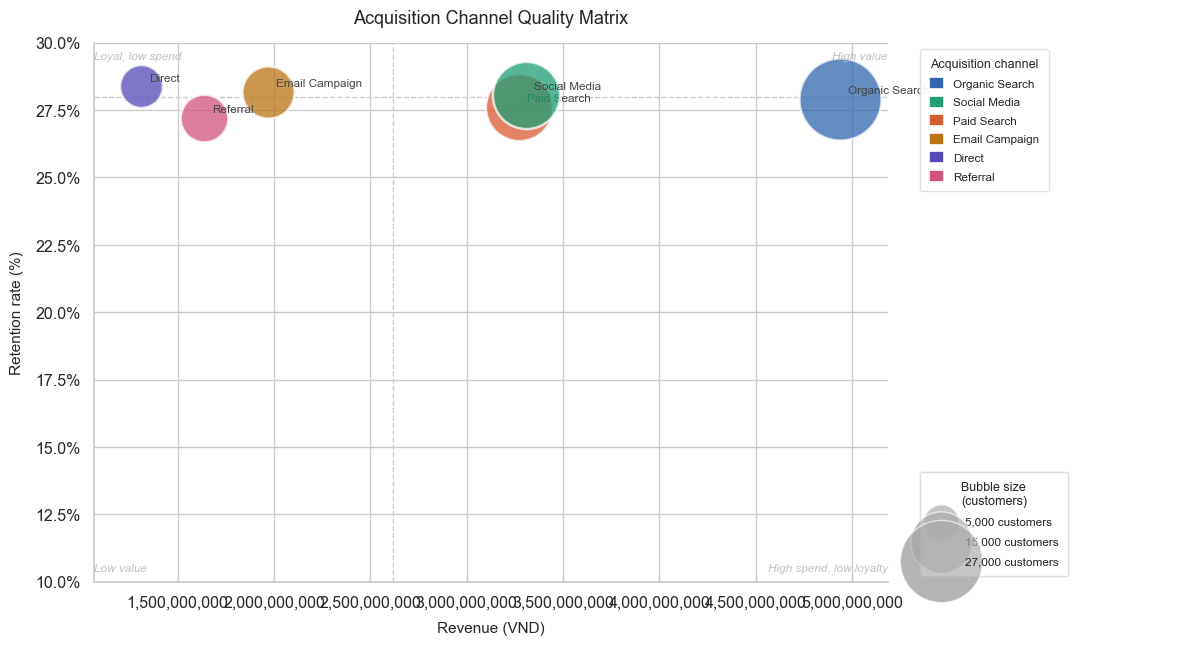

In [7]:
COLORS = {
    'organic_search' : '#3266ad',
    'social_media'   : '#1D9E75',
    'paid_search'    : '#D85A30',
    'email_campaign' : '#BA7517',
    'direct'         : '#534AB7',
    'referral'       : '#D4537E',
}
LABELS = {
    'organic_search' : 'Organic Search',
    'social_media'   : 'Social Media',
    'paid_search'    : 'Paid Search',
    'email_campaign' : 'Email Campaign',
    'direct'         : 'Direct',
    'referral'       : 'Referral',
}
 
# ── Figure: trục chính + 2 cột legend bên phải ──────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
 
# width_ratios: [chart, legend]
fig = plt.figure(figsize=(14, 7))
gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])
ax_leg.axis('off')   # chỉ dùng để đặt legend, không vẽ gì
 
# ── Bubble size ──────────────────────────────────────────────────────────────
max_count = metrics['customers_count'].max()
metrics['bubble_size'] = (metrics['customers_count'] / max_count) * 3500
 
# ── Vẽ bubbles ───────────────────────────────────────────────────────────────
for _, row in metrics.iterrows():
    ch = row['acquisition_channel']
    ax.scatter(
        row['total_revenue'],
        row['retention_rate'],
        s=row['bubble_size'],
        color=COLORS.get(ch, '#888'),
        alpha=0.75,
        edgecolors='white',
        linewidths=1.8,
        zorder=3,
    )
    # Label tên channel ngay cạnh bubble
    ax.annotate(
        LABELS.get(ch, ch),
        xy=(row['total_revenue'], row['retention_rate']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8.5,
        color='#444444',
        fontweight='500',
    )
 

mid_x = metrics['total_revenue'].median()
mid_y = metrics['retention_rate'].median()
 
ax.axvline(mid_x, color='#cccccc', lw=1, ls='--', zorder=1)
ax.axhline(mid_y, color='#cccccc', lw=1, ls='--', zorder=1)
 

ax.set_ylim(10, 30)

pad = metrics['total_revenue'].max() * 0.05  # tham so 
ax.set_xlim(
    metrics['total_revenue'].min() - pad,
    metrics['total_revenue'].max() + pad,
)
 

xl = ax.get_xlim()
yl = ax.get_ylim()
quad_kw = dict(fontsize=8.5, color='#c0c0c0', style='italic')
ax.text(xl[1] - 500,  yl[1] - 0.3, 'High value',              ha='right', va='top',    **quad_kw)
ax.text(xl[0] + 500,  yl[1] - 0.3, 'Loyal, low spend',        ha='left',  va='top',    **quad_kw)
ax.text(xl[1] - 500,  yl[0] + 0.3, 'High spend, low loyalty', ha='right', va='bottom', **quad_kw)
ax.text(xl[0] + 500,  yl[0] + 0.3, 'Low value',               ha='left',  va='bottom', **quad_kw)
 
# ── Axes formatting ──────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.set_xlabel('Revenue (VND)', fontsize=11, labelpad=8)
ax.set_ylabel('Retention rate (%)', fontsize=11, labelpad=8)
ax.set_title('Acquisition Channel Quality Matrix',
             fontsize=13, fontweight='500', pad=14)
sns.despine(ax=ax)
 
# LEGEND 1 — Acquisition Channel (màu)
channel_handles = [
    mpatches.Patch(facecolor=COLORS[ch], edgecolor='white', linewidth=1.2,
                   label=LABELS[ch])
    for ch in COLORS
]
 
leg1 = ax_leg.legend(
    handles=channel_handles,
    title='Acquisition channel',
    title_fontsize=9,
    fontsize=8.5,
    loc='upper left',
    bbox_to_anchor=(0.0, 1.0),
    frameon=True,
    framealpha=0.9,
    edgecolor='#dddddd',
    borderpad=0.8,
    handlelength=1.2,
    handleheight=1.2,
    labelspacing=0.55,
)
ax_leg.add_artist(leg1)
 
# LEGEND 2 — Bubble size (số khách)
size_handles = [
    ax.scatter([], [], s=(ref / max_count) * 3500,
               color='#aaaaaa', alpha=0.65, edgecolors='white', lw=1,
               label=f'{ref:,} customers')
    for ref in [5_000, 15_000, 27_000]
]
 
leg2 = ax_leg.legend(
    handles=size_handles,
    title='Bubble size\n(customers)',
    title_fontsize=9,
    fontsize=8.5,
    loc='lower left',
    bbox_to_anchor=(0.0, 0.0),
    frameon=True,
    framealpha=0.9,
    edgecolor='#dddddd',
    borderpad=0.8,
    handletextpad=1.0,
    labelspacing=0.8,
)
ax_leg.add_artist(leg2)

plt.savefig("../reports/figures/char2a.png")
plt.show()

## Chart 2b 



Công thức tính cohortdata là $
\text{Retention}_t = \frac{\text{Số khách còn hoạt động ở tháng } t}{\text{Tổng khách ban đầu}} \times 100
$

In [8]:
# ── Chỉ lấy đơn hợp lệ (bỏ cancelled / created) ────────────────────────────
valid = ['delivered', 'returned', 'shipped', 'paid']
df = order[order['order_status'].isin(valid)].copy()

# ── Cohort = tháng đặt đơn đầu tiên ────────────────────────────────────────
df["order_date"] = pd.to_datetime(df["order_date"])
df = df[df["order_date"].between("2020-01-01", "2022-12-31")]
df['order_month'] = df['order_date'].dt.to_period('M')
first_order = (
    df.groupby('customer_id')['order_month']
    .min()
    .rename('cohort_month')
    .reset_index()
)
df = df.merge(first_order, on='customer_id')

# ── Số tháng sau lần mua đầu (0 = tháng đầu, 1 = tháng tiếp…) ─────────────
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
df = df[df['month_number'] <= 12]

# ── Cohort size = số khách unique ở tháng đầu tiên sau lần mua đầu  ─────────────────────────────────
cohort_size = (
    df[df['month_number'] == 0]
    .groupby('cohort_month')['customer_id']
    .nunique()
    .rename('cohort_size')
)   

# ── Active customers per (cohort, month) ────────────────────────────────────
cohort_data = (
    df.groupby(['cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)
cohort_data = cohort_data.merge(cohort_size, on='cohort_month')
# công thức tích retention_rate : 
cohort_data['retention_rate'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
)

# ── Pivot → matrix (bỏ month 0 vì luôn = 100%) ─────────────────────────────
pivot = (
    cohort_data[cohort_data['month_number'] >= 1]
    .pivot_table(index='cohort_month', columns='month_number', values='retention_rate')
)
pivot.index = pivot.index.astype(str)
pivot.columns = [f'M+{c}' for c in pivot.columns]

# ── Gộp theo năm (median) cho dễ đọc ────────────────────────────────────────
pivot['year'] = pivot.index.str[:4]
pivot_year = pivot.groupby('year').median(numeric_only=True)
pivot_year

,M+1,M+2,M+3,M+4,M+5,M+6,M+7,M+8,M+9,M+10,M+11,M+12
year,,,,,,,,,,,,
2020,5.214366,4.383837,4.526110,4.457630,4.764719,4.608094,4.883146,4.348473,4.954955,4.814937,4.968261,5.120208
2021,3.526240,3.490012,2.888481,3.535596,2.854057,3.366635,3.338719,3.164409,3.316597,3.059096,3.383245,3.381394
2022,2.822581,2.982685,3.594771,3.223305,3.104575,2.321294,2.621723,2.517136,2.181208,2.284044,1.612903,NaN


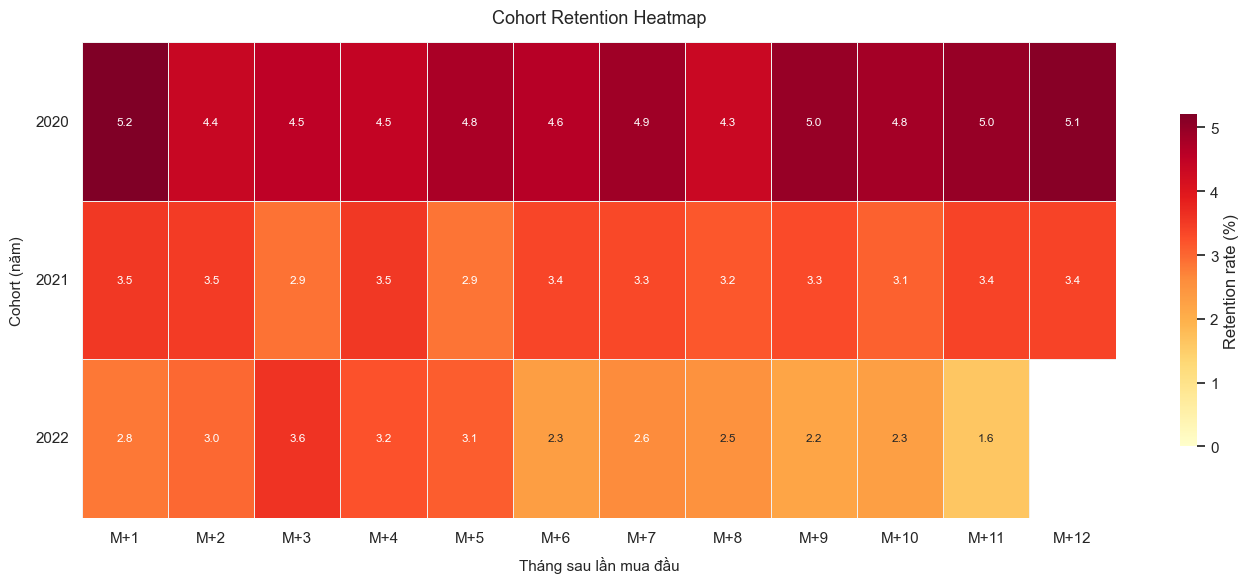

In [9]:

sns.set_theme(style='white', font_scale=1.0)

fig, ax = plt.subplots(figsize=(14, 6))

mask = pivot_year.isna()

sns.heatmap(
    pivot_year,
    ax=ax,
    mask=mask,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 8.5, 'weight': '500'},
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#f0f0f0',
    cbar_kws={'label': 'Retention rate (%)', 'shrink': 0.7},
    vmin=0,
)

# Tô ô NaN màu xám nhạt
sns.heatmap(
    pivot_year,
    ax=ax,
    mask=~mask,
    annot=False,
    cmap=['#f5f5f5'],
    linewidths=0.4,
    linecolor='#f0f0f0',
    cbar=False,
    vmin=0, vmax=1,
)

ax.set_title('Cohort Retention Heatmap',
             fontsize=13, fontweight='500', pad=14)
ax.set_xlabel('Tháng sau lần mua đầu', fontsize=11, labelpad=8)
ax.set_ylabel('Cohort (năm)', fontsize=11, labelpad=8)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.savefig("../reports/figures/char2b_year.png")
plt.tight_layout()
plt.show()

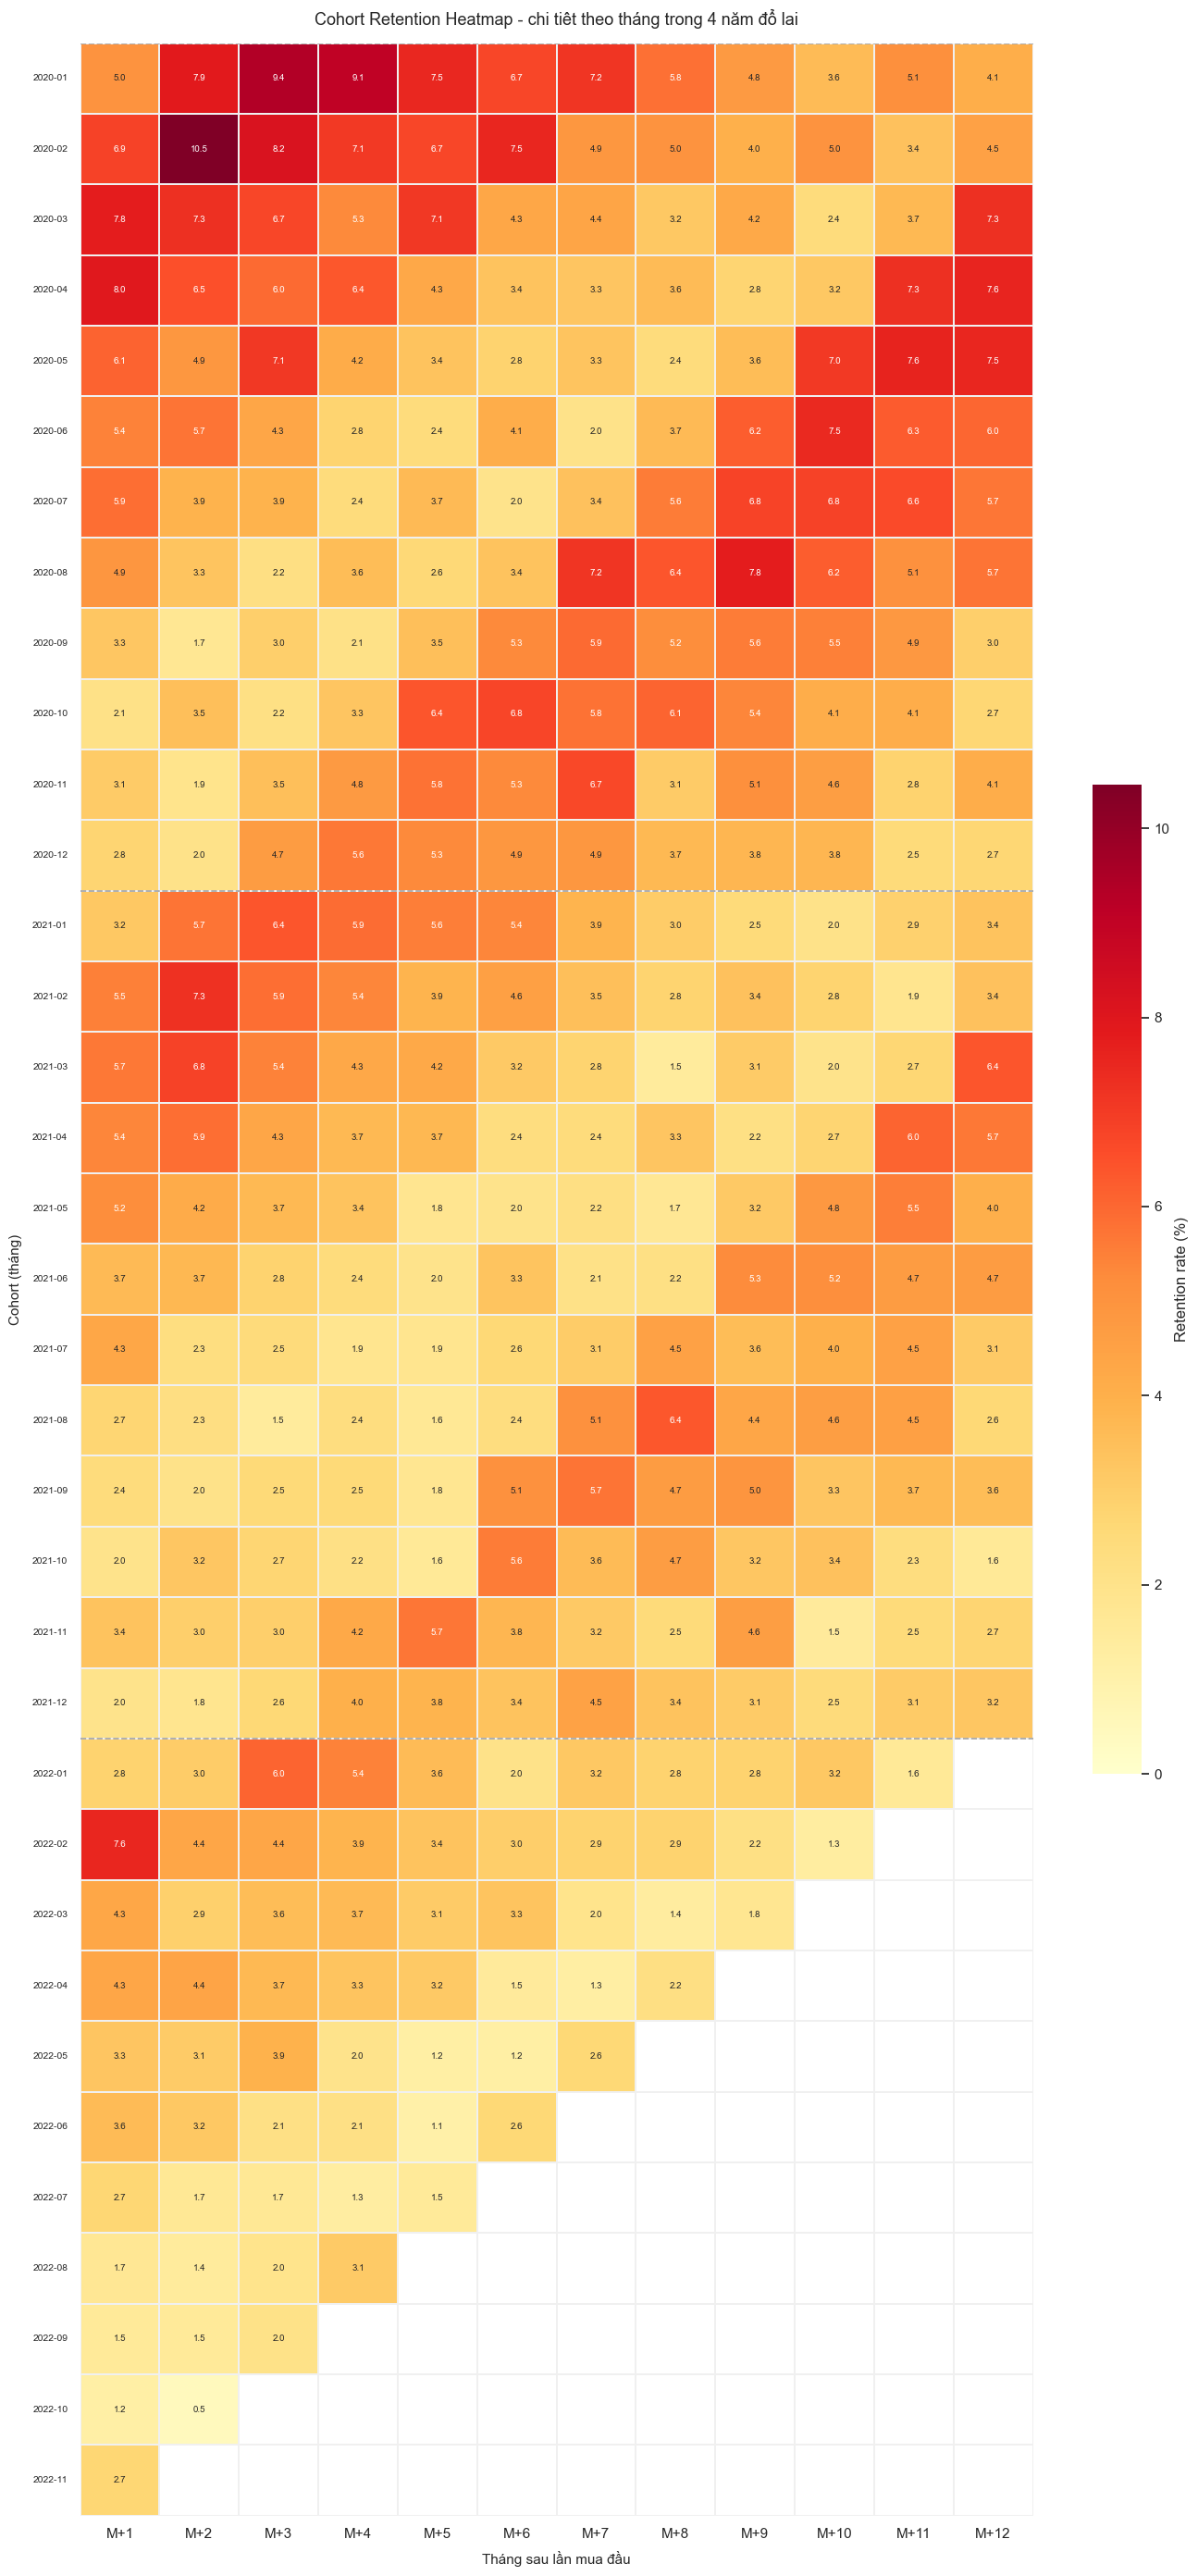

In [10]:
pivot_plot = pivot.drop(columns='year')
mask2 = pivot_plot.isna()

fig, ax = plt.subplots(figsize=(14, 28))

sns.heatmap(
    pivot_plot,
    ax=ax,
    mask=mask2,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#f0f0f0',
    cbar_kws={'label': 'Retention rate (%)', 'shrink': 0.4},
    vmin=0,
)
sns.heatmap(
    pivot_plot,
    ax=ax,
    mask=~mask2,
    annot=False,
    cmap=['#f5f5f5'],
    linewidths=0.3,
    linecolor='#f0f0f0',
    cbar=False,
    vmin=0, vmax=1,
)

# Vẽ đường phân cách theo năm
year_boundaries = (
    pivot_plot.index.str[:4]
    .to_series()
    .reset_index(drop=True)
    .ne(pivot_plot.index.str[:4]
        .to_series()
        .reset_index(drop=True)
        .shift())
    .where(lambda x: x)
    .dropna()
    .index
    .tolist()
)
for boundary in year_boundaries:
    ax.axhline(boundary, color='#555', linewidth=1.2, linestyle='--', alpha=0.5)

ax.set_title('Cohort Retention Heatmap - chi tiêt theo tháng trong 4 năm đổ lai',
             fontsize=13, fontweight='500', pad=14)
ax.set_xlabel('Tháng sau lần mua đầu', fontsize=11, labelpad=8)
ax.set_ylabel('Cohort (tháng)', fontsize=11, labelpad=8)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0, labelsize=7.5)
plt.savefig('../reports/figures/char2b_2.png')
plt.tight_layout()
plt.show()

### gen du lieu tu nam 2012 toi 2022 de ve cohort curve 

In [11]:
# ── Chỉ lấy đơn hợp lệ (bỏ cancelled / created) ────────────────────────────
valid = ['delivered', 'returned', 'shipped', 'paid']
df = order[order['order_status'].isin(valid)].copy()

# ── Cohort = tháng đặt đơn đầu tiên ────────────────────────────────────────
df["order_date"] = pd.to_datetime(df["order_date"])
df['order_month'] = df['order_date'].dt.to_period('M')
first_order = (
    df.groupby('customer_id')['order_month']
    .min()
    .rename('cohort_month')
    .reset_index()
)
df = df.merge(first_order, on='customer_id')

# ── Số tháng sau lần mua đầu (0 = tháng đầu, 1 = tháng tiếp…) ─────────────
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)
df = df[df['month_number'] <= 12]

# ── Cohort size = số khách unique ở tháng đầu tiên sau lần mua đầu  ─────────────────────────────────
cohort_size = (
    df[df['month_number'] == 0]
    .groupby('cohort_month')['customer_id']
    .nunique()
    .rename('cohort_size')
)

# ── Active customers per (cohort, month) ────────────────────────────────────
cohort_data = (
    df.groupby(['cohort_month', 'month_number'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'active_customers'})
)
cohort_data = cohort_data.merge(cohort_size, on='cohort_month')
# công thức tích retention_rate : 
cohort_data['retention_rate'] = (
    cohort_data['active_customers'] / cohort_data['cohort_size'] * 100
)

# ── Pivot → matrix (bỏ month 0 vì luôn = 100%) ─────────────────────────────
pivot = (
    cohort_data[cohort_data['month_number'] >= 1]
    .pivot_table(index='cohort_month', columns='month_number', values='retention_rate')
)
pivot.index = pivot.index.astype(str)
pivot.columns = [f'M+{c}' for c in pivot.columns]

# ── Gộp theo năm (median) cho dễ đọc ────────────────────────────────────────
pivot['year'] = pivot.index.str[:4]
pivot_year = pivot.groupby('year').median(numeric_only=True)
pivot_year

,M+1,M+2,M+3,M+4,M+5,M+6,M+7,M+8,M+9,M+10,M+11,M+12
year,,,,,,,,,,,,
2012,9.744495,8.370350,8.347477,9.730036,11.330816,11.137451,11.461811,13.331185,12.741719,12.255684,11.719190,9.765576
2013,7.076491,6.902602,5.361378,5.731274,6.805511,5.854912,6.395822,6.586280,6.807677,6.763189,7.282040,7.369799
2014,4.471133,3.616324,3.863292,3.578049,4.304766,3.797516,3.535093,3.771776,3.564119,4.109946,4.241026,4.070489
2015,3.636123,3.331100,2.693272,2.939023,3.100698,2.724341,2.994908,2.984552,2.828613,2.763666,3.002394,3.374407
2016,2.265568,2.766798,1.875249,1.643784,2.042053,1.542671,1.827498,1.755570,1.986727,2.342132,2.623074,2.365707
2017,1.887464,1.886792,1.886792,2.103463,1.455301,1.616103,1.673904,2.056375,1.415598,1.180641,1.694915,1.277582
2018,1.286506,1.695944,1.158069,1.134602,1.057082,0.651466,1.149539,0.850340,0.917431,0.814332,1.238972,0.653595
2019,1.362569,1.250000,0.980392,0.540541,0.928779,0.859788,0.925926,1.130051,1.418651,0.968013,0.917431,0.976749
2020,1.143135,1.008331,0.980392,0.807767,0.796373,1.320492,0.653595,1.250000,0.662368,1.342282,1.001227,0.649351


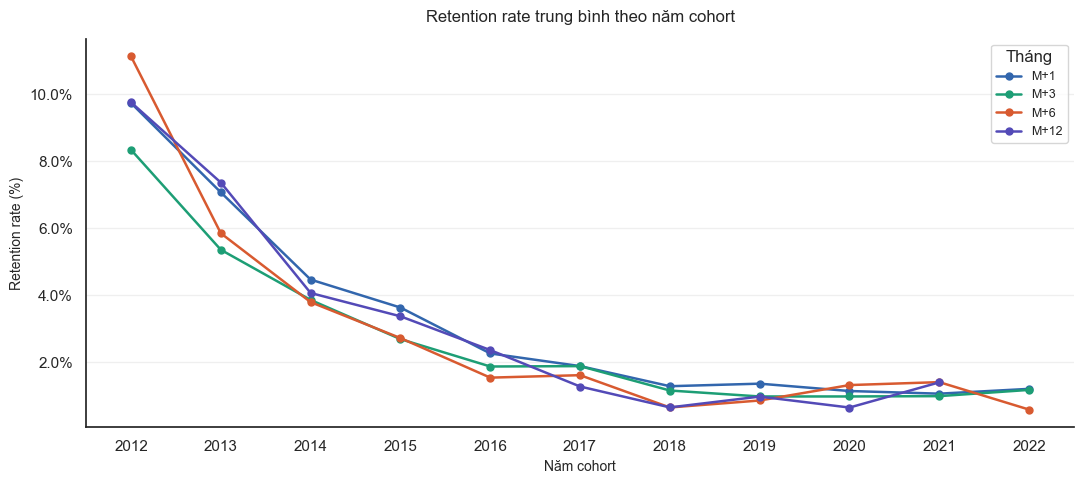

In [12]:
trend = pivot_year[['M+1', 'M+3', 'M+6', 'M+12']].copy()

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#3266ad', '#1D9E75', '#D85A30', '#534AB7']

for col, color in zip(trend.columns, colors):
    ax.plot(trend.index, trend[col], marker='o', label=col,
            color=color, linewidth=1.8, markersize=5)

ax.set_title('Retention rate trung bình theo năm cohort',
             fontsize=12, fontweight='500', pad=12)
ax.set_xlabel('Năm cohort', fontsize=10)
ax.set_ylabel('Retention rate (%)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(title='Tháng', fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("../reports/figures/chart2b_3.png")
plt.show()

## Char2c


Phân loại đơn hàng 

In [13]:
# Chỉ lấy đơn hợp lệ
valid = ['delivered', 'shipped', 'paid']
df = order.copy()

# Revenue từ order_items
order_items['revenue'] = (
    order_items['unit_price'] * order_items['quantity']
)
order_rev = order_items.groupby('order_id')['revenue'].sum().reset_index()
df = df.merge(order_rev, on='order_id', how='left')
df["order_date"] = pd.to_datetime(df["order_date"])
df['year'] = df['order_date'].dt.year

# ── Phân loại: first_order vs repeat_order ──────────────────────────────────
# Sắp xếp theo customer + ngày để xác định thứ tự mua
df = df.sort_values(['customer_id', 'order_date'])
df['order_rank'] = df.groupby('customer_id').cumcount() + 1
df['order_type'] = df['order_rank'].apply(lambda x: 'New customer' if x == 1 else 'Repeat customer')


df

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,revenue,year,order_rank,order_type
4023,5280,2012-07-25,1,15201,delivered,cod,desktop,paid_search,12627.39,2012,1,New customer
143252,184922,2014-05-31,1,15201,returned,credit_card,mobile,referral,1478.78,2014,2,Repeat customer
238890,308113,2015-07-31,1,15201,delivered,cod,mobile,paid_search,44708.32,2015,3,Repeat customer
374571,483190,2017-04-23,1,15201,delivered,cod,mobile,paid_search,37213.40,2017,4,Repeat customer
544446,702081,2020-02-24,1,15201,delivered,credit_card,mobile,organic_search,4233.33,2020,5,Repeat customer
...,...,...,...,...,...,...,...,...,...,...,...,...
549990,709267,2020-04-11,157563,59937,delivered,credit_card,mobile,email_campaign,23522.32,2020,18,Repeat customer
557438,718824,2020-05-29,157563,59937,delivered,credit_card,mobile,social_media,139689.28,2020,19,Repeat customer
559725,721751,2020-06-22,157563,59937,delivered,paypal,tablet,organic_search,12002.81,2020,20,Repeat customer
591841,763157,2021-05-27,157563,59937,delivered,credit_card,mobile,social_media,28317.52,2021,21,Repeat customer


In [14]:
sales

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [15]:
df.groupby("order_date")["revenue"].sum()

order_date
2012-07-04    5123547.94
2012-07-05    2751773.45
2012-07-06    3054029.42
2012-07-07    2667930.94
2012-07-08    2360851.90
                 ...    
2022-12-27    2100553.66
2022-12-28    3448729.20
2022-12-29    3083944.33
2022-12-30    2884668.76
2022-12-31    2383037.48
Name: revenue, Length: 3833, dtype: float64

In [16]:
# Revenue tuyệt đối
rev = (
    df.groupby(['year', 'order_type'])['revenue']
    .sum().reset_index()
    .pivot(index='year', columns='order_type', values='revenue')
    .fillna(0)
)
rev.columns.name = None
rev['Total'] = rev.sum(axis=1)
rev['pct_new']    = rev['New customer']    / rev['Total'] * 100
rev['pct_repeat'] = rev['Repeat customer'] / rev['Total'] * 100

# Số đơn
cnt = (
    df.groupby(['year', 'order_type'])['order_id']
    .count().reset_index()
    .pivot(index='year', columns='order_type', values='order_id')
    .fillna(0).astype(int)
)
cnt.columns.name = None

summary = rev.join(cnt, rsuffix='_orders')

### Vẽ chart 

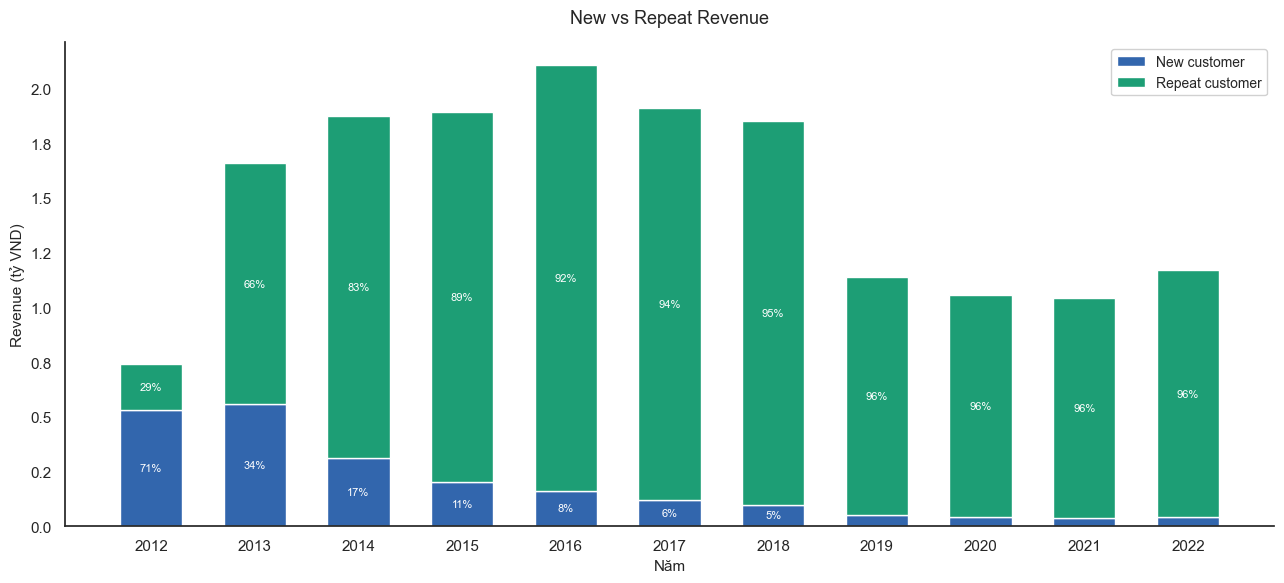

In [17]:
C_NEW    = '#3266ad'
C_REPEAT = '#1D9E75'

years = rev.index.tolist()
new_rev    = rev['New customer'] / 1e9
repeat_rev = rev['Repeat customer'] / 1e9

fig, ax = plt.subplots(figsize=(13, 6))

bars_new    = ax.bar(years, new_rev,    color=C_NEW,    label='New customer',    width=0.6)
bars_repeat = ax.bar(years, repeat_rev, color=C_REPEAT, label='Repeat customer', width=0.6,
                     bottom=new_rev)

# Ghi % lên từng segment
for i, year in enumerate(years):
    pn = rev.loc[year, 'pct_new']
    pr = rev.loc[year, 'pct_repeat']
    nv = new_rev.iloc[i]
    rv = repeat_rev.iloc[i]

    # % new (trong bar xanh dương) — chỉ hiện nếu đủ cao
    if nv > 0.05:
        ax.text(year, nv / 2, f'{pn:.0f}%',
                ha='center', va='center', fontsize=8,
                color='white', fontweight='500')
    # % repeat (trong bar xanh lá)
    if rv > 0.05:
        ax.text(year, nv + rv / 2, f'{pr:.0f}%',
                ha='center', va='center', fontsize=8,
                color='white', fontweight='500')

ax.set_xlabel('Năm', fontsize=11)
ax.set_ylabel('Revenue (tỷ VND)', fontsize=11)
ax.set_title('New vs Repeat Revenue',
             fontsize=13, fontweight='500', pad=14)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.legend(fontsize=10, frameon=True, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig("../reports/figures/chart2c.png")
plt.show()

## chart2d


Tiền marketing đổ vào có chuyển được thành doanh thu không ?

In [18]:
# Revenue từ order_items
order_items['revenue'] = (
    order_items['unit_price'] * order_items['quantity']
)
order_rev = order_items.groupby('order_id')['revenue'].sum().reset_index()

valid = ['delivered', 'shipped', 'paid']
df = order.copy()

df = df.merge(order_rev, on='order_id', how='left')
df["order_date"] = pd.to_datetime(df["order_date"])
df['date'] = df['order_date'].dt.normalize()

# Tổng orders & revenue mỗi (date, order_source)
daily_orders = (
    df.groupby(['date', 'order_source'])
    .agg(orders_count=('order_id', 'count'), revenue=('revenue', 'sum'))
    .reset_index()
    .rename(columns={'order_source': 'traffic_source'})
)

# Join web_traffic × daily_orders theo date + traffic_source
web_traffic["date"] = pd.to_datetime(web_traffic["date"])

merged = web_traffic.merge(daily_orders, on=['date', 'traffic_source'], how='left')

merged['orders_count'] = merged['orders_count'].fillna(0)
merged['revenue']      = merged['revenue'].fillna(0)
merged['year']         = merged['date'].dt.year

yearly_summary = (
    merged.groupby('year')
    .agg(
        sessions=('sessions', 'sum'),
        orders_count=('orders_count', 'sum'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)

# Metrics hàng ngày
yearly_summary['conversion_rate']     = yearly_summary['orders_count'] / yearly_summary['sessions'] * 100
yearly_summary['revenue_per_session'] = yearly_summary['revenue']      / yearly_summary['sessions']

print(f'Web traffic rows : {len(web_traffic):,}')
print(f'Merged rows      : {len(yearly_summary):,}')
yearly_summary.head(3)

Web traffic rows : 3,652
Merged rows      : 10


,year,sessions,orders_count,revenue,conversion_rate,revenue_per_session
0,2013,6801940,15412.0,3.313817e+08,0.226582,48.718701
1,2014,7340960,16030.0,3.695927e+08,0.218364,50.346641
2,2015,7861938,16848.0,3.874961e+08,0.214298,49.287608


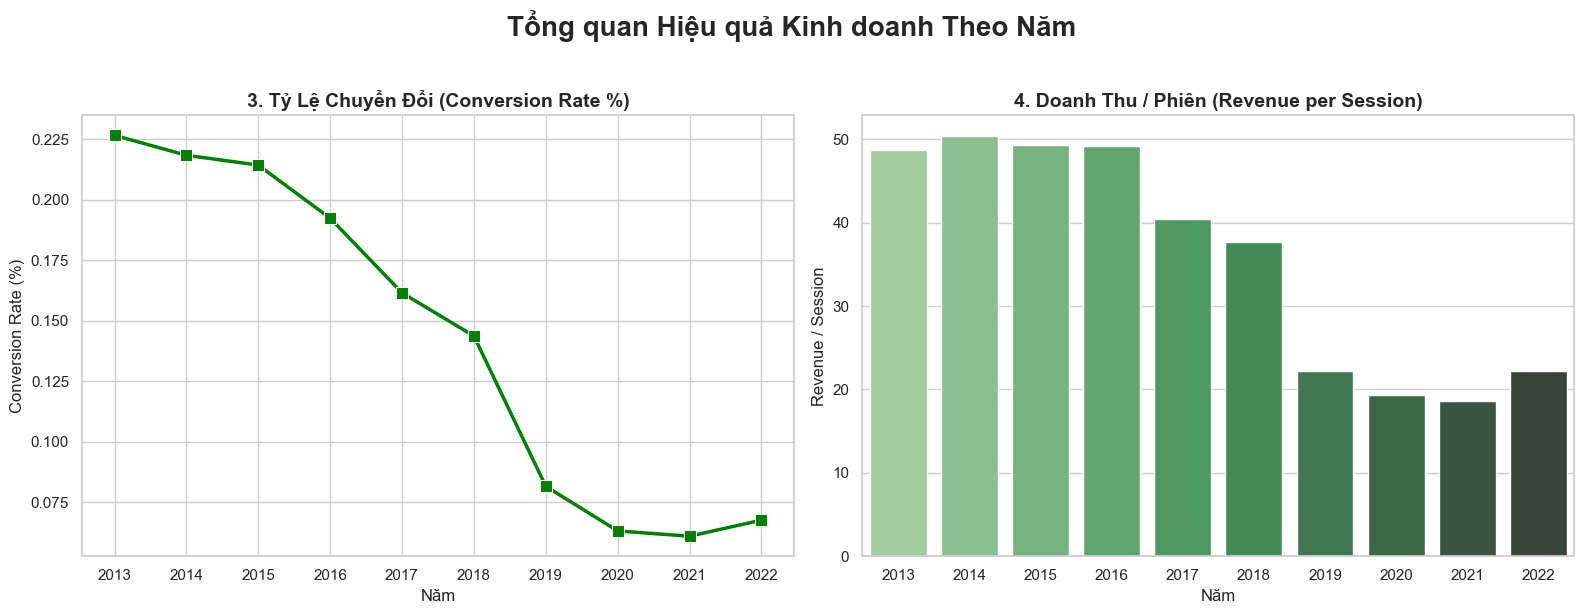

In [19]:
# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")

# Tạo khung hình với 4 biểu đồ (2 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tổng quan Hiệu quả Kinh doanh Theo Năm', fontsize=20, fontweight='bold', y=1.02)

# --- Biểu đồ 3: Tỷ Lệ Chuyển Đổi (Conversion Rate) ---
sns.lineplot(data=yearly_summary, x='year', y='conversion_rate', ax=axes[0], marker='s', color='green', linewidth=2.5, markersize=8)
axes[0].set_title('3. Tỷ Lệ Chuyển Đổi (Conversion Rate %)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_xlabel('Năm', fontsize=12)
axes[0].set_xticks(yearly_summary['year']) # Hiển thị chính xác các năm trên trục X

# --- Biểu đồ 4: Doanh thu trên mỗi phiên (Revenue per Session) ---
sns.barplot(data=yearly_summary, x='year', y='revenue_per_session', ax=axes[1], palette='Greens_d')
axes[1].set_title('4. Doanh Thu / Phiên (Revenue per Session)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue / Session', fontsize=12)
axes[1].set_xlabel('Năm', fontsize=12)

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.savefig("../reports/figures/chart2d.png")
# Hiển thị biểu đồ
plt.show()

### He so tuong quan (Correlation) 